# Harder regression: augment MiSTIC with a full-data model

This notebook tests whether a linear MiSTIC set benefits from an additional
model trained on all 375 available training observations. The blind set remains
untouched. For every seed, the 20-member forward-knee ensemble is fitted exactly
as before at `rank_weight=0.75`. A separate linear SVR is then tuned by four-fold
CV and refitted on all training rows using that ensemble's knee-ranked unified
features.

Two predetermined combinations are evaluated:

1. **Literal 21st member:** `(20 × set prediction + full-model prediction) / 21`.
2. **Equal model/set blend:** `0.5 × set prediction + 0.5 × full-model prediction`.

The blend weights are fixed in advance and never selected using blind results.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.75
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]
POLY_DEGREES = [2, 3]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=60.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.30 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=1.42e-17, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, kernel_type):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type=kernel_type),
        separate_feature_sets=True, separate_parameters=True,
    )
    if kernel_type == "linear":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon}, kernel={})
            for c in C_VALUES for epsilon in EPSILON_VALUES
        ]
    elif kernel_type == "rbf":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon},
                     kernel={"gamma": gamma})
            for c in C_VALUES for gamma in GAMMA_VALUES
            for epsilon in EPSILON_VALUES
        ]
    elif kernel_type == "polynomial":
        grid = [
            paramSet(model={"C": c, "epsilon": epsilon},
                     kernel={"gamma": gamma, "degree": degree, "coef0": 1.0})
            for c in C_VALUES for gamma in GAMMA_VALUES
            for epsilon in EPSILON_VALUES for degree in POLY_DEGREES
        ]
    else:
        raise ValueError(kernel_type)
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=RANK_WEIGHT).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the augmented linear ensemble

Only the linear-kernel MiSTIC configuration is rerun. The full-data model uses
the same C and epsilon grid as the linear members.


In [4]:
rows = []
NUM_MODELS = 20
for seed in INNER_SEEDS:
    started = time.perf_counter()
    scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, "linear")
    X_blind_scaled = scaler.transform(X_blind)
    set_predictions = np.asarray(ensemble.predict(X_blind_scaled))
    unified_features = ranked_unified_features(ensemble, knee_count)

    full_search = GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="linear"))]),
        {"svr__C": C_VALUES, "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    ).fit(X_train.iloc[:, unified_features], y_train)
    full_predictions = np.asarray(
        full_search.predict(X_blind.iloc[:, unified_features])
    )

    prediction_sets = {
        "MiSTIC set only": set_predictions,
        "Full-data unified SVR only": full_predictions,
        "Augmented: full SVR as 21st member":
            (NUM_MODELS * set_predictions + full_predictions) / (NUM_MODELS + 1),
        "Blend: 50% set + 50% full SVR":
            0.5 * set_predictions + 0.5 * full_predictions,
    }
    for method, predictions in prediction_sets.items():
        rows.append({
            "seed": seed, "method": method, "num_models": NUM_MODELS,
            "knee_feature_count": knee_count,
            "num_unified_reference_features": len(unified_features),
            "full_model_cv_score": full_search.best_score_,
            "full_model_C": full_search.best_params_["svr__C"],
            "full_model_epsilon": full_search.best_params_["svr__epsilon"],
            **metric_row(y_blind, predictions),
        })
    print(f"seed={seed}, knee={knee_count}, elapsed={time.perf_counter()-started:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_harder_full_data_augmentation_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.075


Number of Features: 10, Score: 0.658


Number of Features: 19, Score: 0.808


Number of Features: 20, Score: 0.809


Number of Features: 100, Score: 0.784


...

Number of Features: 19, Score: 0.807


Number of Features: 20, Score: 0.811


Number of Features: 100, Score: 0.789


seed=9, knee=19, elapsed=28.8s


,seed,method,num_models,knee_feature_count,num_unified_reference_features,full_model_cv_score,full_model_C,full_model_epsilon,r2,rmse,mae,pearson_r2
0,0,MiSTIC set only,20,19,19,0.864156,0.25,0.10,0.775632,0.404829,0.313959,0.776438
1,0,Full-data unified SVR only,20,19,19,0.864156,0.25,0.10,0.812237,0.370336,0.295187,0.814858
2,0,Augmented: full SVR as 21st member,20,19,19,0.864156,0.25,0.10,0.778296,0.402419,0.311969,0.779098
3,0,Blend: 50% set + 50% full SVR,20,19,19,0.864156,0.25,0.10,0.799007,0.383161,0.298910,0.800123
4,1,MiSTIC set only,20,19,19,0.863612,0.25,0.20,0.790968,0.390748,0.310023,0.791612
5,1,Full-data unified SVR only,20,19,19,0.863612,0.25,0.20,0.809588,0.372939,0.300569,0.814284
6,1,Augmented: full SVR as 21st member,20,19,19,0.863612,0.25,0.20,0.793037,0.388809,0.308752,0.793669
7,1,Blend: 50% set + 50% full SVR,20,19,19,0.863612,0.25,0.20,0.806796,0.375663,0.300997,0.808112
8,2,MiSTIC set only,20,19,19,0.859874,0.25,0.10,0.785262,0.396046,0.313623,0.785439
9,2,Full-data unified SVR only,20,19,19,0.859874,0.25,0.10,0.803935,0.378435,0.307560,0.806740


In [5]:
summary = results.groupby("method")[[
    "r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
    "num_unified_reference_features", "full_model_cv_score"
]].agg(["mean", "std"])
summary.round(5)


r2              rmse           \
                                       mean      std     mean      std   
method                                                                   
Augmented: full SVR as 21st member  0.78523  0.00858  0.39601  0.00786   
Blend: 50% set + 50% full SVR       0.80103  0.00534  0.38120  0.00509   
Full-data unified SVR only          0.80842  0.00643  0.37403  0.00624   
MiSTIC set only                     0.78306  0.00911  0.39799  0.00831   

                                        mae          pearson_r2           \
                                       mean      std       mean      std   
method                                                                     
Augmented: full SVR as 21st member  0.31169  0.00454    0.78590  0.00871   
Blend: 50% set + 50% full SVR       0.30183  0.00421    0.80238  0.00538   
Full-data unified SVR only          0.29926  0.00623    0.81240  0.00576   
MiSTIC set only                     0.31317  0.00483    0.78372  0.00922   

                                   knee_feature_count           \
                                                 mean      std   
method                                                           
Augmented: full SVR as 21st member               19.2  0.42164   
Blend: 50% set + 50% full SVR                    19.2  0.42164   
Full-data unified SVR only                       19.2  0.42164   
MiSTIC set only                                  19.2  0.42164   

                                   num_unified_reference_features           \
                                                             mean      std   
method                                                                       
Augmented: full SVR as 21st member                           19.2  0.42164   
Blend: 50% set + 50% full SVR                                19.2  0.42164   
Full-data unified SVR only                                   19.2  0.42164   
MiSTIC set only                                              19.2  0.42164   

                                   full_model_cv_score           
                                                  mean      std  
method                                                           
Augmented: full SVR as 21st member             0.86003  0.00378  
Blend: 50% set + 50% full SVR                  0.86003  0.00378  
Full-data unified SVR only                     0.86003  0.00378  
MiSTIC set only                                0.86003  0.00378

In [6]:
baseline = results.query("method == 'MiSTIC set only'").set_index("seed")
paired_rows = []
for method, frame in results.groupby("method"):
    if method == "MiSTIC set only":
        continue
    other = frame.set_index("seed")
    for metric in ["r2", "rmse", "mae"]:
        improvement = other[metric] - baseline[metric]
        if metric in ["rmse", "mae"]:
            improvement = -improvement
        paired_rows.append({
            "method": method, "metric": metric,
            "mean_improvement_over_set": improvement.mean(),
            "std_difference": improvement.std(ddof=1),
            "method_wins": int((improvement > 0).sum()),
            "ties": int((improvement == 0).sum()),
            "method_losses": int((improvement < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(5)


,method,metric,mean_improvement_over_set,std_difference,method_wins,ties,method_losses
0,Augmented: full SVR as 21st member,r2,0.00217,0.00064,10,0,0
1,Augmented: full SVR as 21st member,rmse,0.00199,0.00056,10,0,0
2,Augmented: full SVR as 21st member,mae,0.00148,0.00044,10,0,0
3,Blend: 50% set + 50% full SVR,r2,0.01797,0.00588,10,0,0
4,Blend: 50% set + 50% full SVR,rmse,0.01680,0.00532,10,0,0
5,Blend: 50% set + 50% full SVR,mae,0.01134,0.00408,10,0,0
6,Full-data unified SVR only,r2,0.02536,0.01025,10,0,0
7,Full-data unified SVR only,rmse,0.02396,0.00955,10,0,0
8,Full-data unified SVR only,mae,0.01391,0.00665,10,0,0


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_89488/1115408532.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=results, y="method", x="r2", order=order,


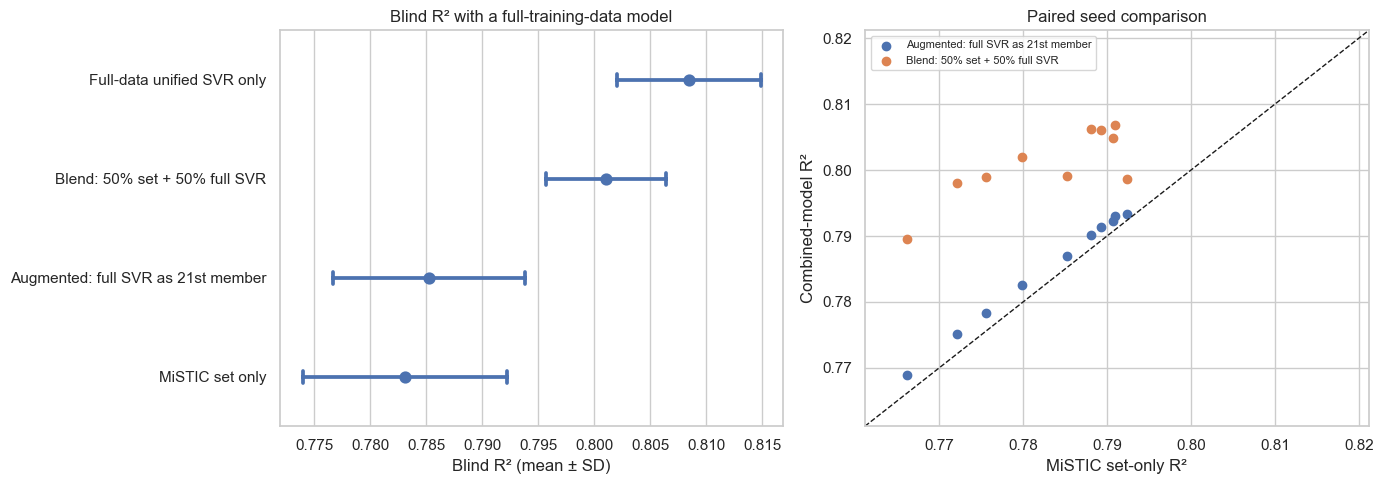

In [7]:
order = results.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.pointplot(data=results, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.12, ax=axes[0])
axes[0].set_title("Blind R² with a full-training-data model")
axes[0].set_xlabel("Blind R² (mean ± SD)")
axes[0].set_ylabel("")
wide = results.pivot(index="seed", columns="method", values="r2")
for method in ["Augmented: full SVR as 21st member", "Blend: 50% set + 50% full SVR"]:
    axes[1].scatter(wide["MiSTIC set only"], wide[method], label=method)
limits = [results["r2"].min() - 0.005, results["r2"].max() + 0.005]
axes[1].plot(limits, limits, "k--", linewidth=1)
axes[1].set_xlim(limits); axes[1].set_ylim(limits)
axes[1].set_xlabel("MiSTIC set-only R²")
axes[1].set_ylabel("Combined-model R²")
axes[1].set_title("Paired seed comparison")
axes[1].legend(fontsize=8)
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_harder_full_data_augmentation_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

The full-data model uses all training samples but only the seed-specific
knee-ranked unified features. The blind set is never included in training,
tuning, feature selection, or blend-weight selection. All seeds share the same
blind observations.
